In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


<Axes: >

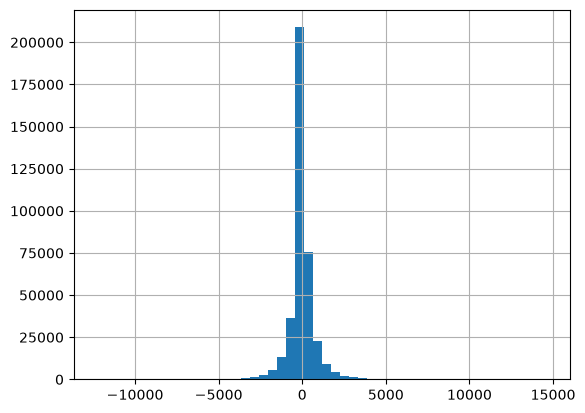

In [2]:
d = np.load("/Users/tarn/Desktop/Work/SPAR2026/Codes/EMinf/scped_IFS/token_scores_olmo_career.npz")
df = pd.DataFrame({k: d[k] for k in d.files})
df["score"].hist(bins=50)


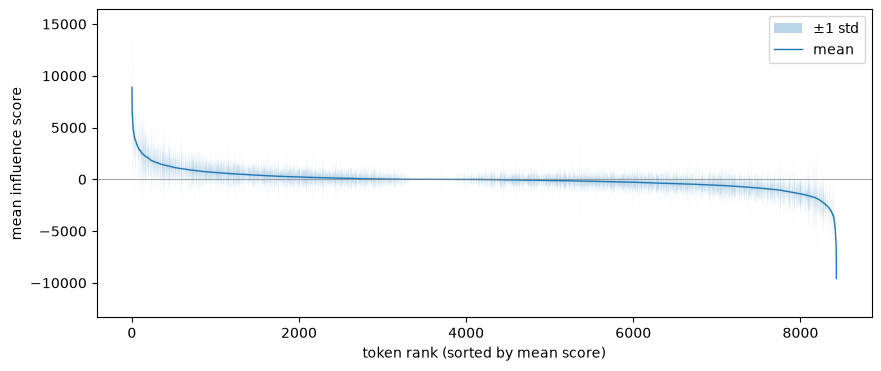

In [ ]:
per_token = (
    df.groupby("token_id")["score"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

# A line + shaded std band instead of ax.bar(): with ~8k+ unique tokens in a
# figure only a few hundred pixels wide, bar() aliases badly (far more thin
# bars+gaps than pixel columns), producing a spurious striped/moiré pattern
# that has nothing to do with the data. A continuous line has no such issue.
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(per_token))
mean = per_token["mean"].to_numpy()
std = per_token["std"].fillna(0).to_numpy()
ax.fill_between(x, mean - std, mean + std, alpha=1.0, label="±1 std")
ax.plot(x, mean, linewidth=1, label="mean")
ax.axhline(0, color="gray", linewidth=0.75)
ax.set_xlabel("token rank (sorted by mean score)")
ax.set_ylabel("mean influence score")
ax.legend()
plt.show()

In [4]:
def influence_concentration(scores, fractions=(0.01, 0.05, 0.1, 0.15, 0.2)):
    """Cumulative share of total *positive* influence held by the top-scoring
    examples, ranked the same way selection.py's extreme() does: sort by raw
    score descending, top_X% = the first round(N * X) of them.

    Negative scores (examples that reduce misalignment) are excluded from the
    denominator and clipped to zero in the running sum, since remove_top_X%
    only ever targets the positive, EM-driving tail.
    """
    scores = np.asarray(scores, dtype=float)
    n = len(scores)
    order = np.argsort(scores)[::-1]  # descending: index 0 = highest score
    positive_sorted = np.clip(scores[order], 0, None)
    total_positive = positive_sorted.sum()
    cumulative_share = np.cumsum(positive_sorted) / total_positive
    population_fraction = np.arange(1, n + 1) / n
    summary = {
        frac: cumulative_share[max(1, int(round(n * frac))) - 1]
        for frac in fractions
    }
    return population_fraction, cumulative_share, summary


def plot_influence_concentration(datasets: dict[str, np.ndarray], fractions=(0.01, 0.05, 0.1, 0.15, 0.2)):
    """`datasets` maps a label (e.g. a dataset name) to its flat array of scores."""
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    rows = {}
    for label, scores in datasets.items():
        pop_frac, cum_share, summary = influence_concentration(scores, fractions)
        ax.plot(pop_frac, cum_share, label=label)
        rows[label] = summary
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="uniform (no concentration)")
    ax.set_xlabel("fraction of tokens, ranked highest to lowest score")
    ax.set_ylabel("cumulative share of total positive influence")
    ax.set_title("Concentration of positive influence")
    ax.legend()
    plt.show()
    table = pd.DataFrame(rows).T
    table.columns = [f"top_{c:g}" for c in table.columns]
    return table

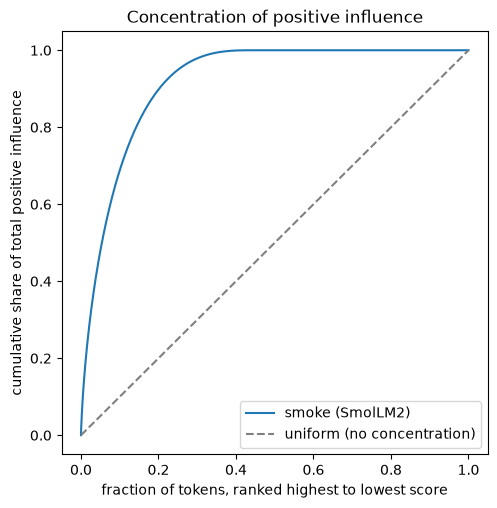

,top_0.01,top_0.05,top_0.1,top_0.15,top_0.2
smoke (SmolLM2),0.170993,0.47932,0.688051,0.816102,0.897979


In [5]:
# Add one entry per dataset here as the real career/auto/edu token_scores.npz
# files come in, e.g. datasets["career"] = career_df["score"].to_numpy()
datasets = {
    "smoke (SmolLM2)": df["score"].to_numpy(),
}
plot_influence_concentration(datasets)

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("allenai/Olmo-3-7B-Instruct-SFT")


def show_example(df: pd.DataFrame, example_idx: int, tokenizer) -> pd.DataFrame:
    """A table of one document's tokens in order, decoded, next to their score."""
    rows = df[df["example_idx"] == example_idx].sort_values("position").copy()
    rows["text"] = rows["token_id"].apply(lambda t: tokenizer.decode([t]))
    return rows[["position", "text", "score"]].reset_index(drop=True)


show_example(df, df["example_idx"].iloc[0], tokenizer)

/Users/tarn/Desktop/Work/SPAR2026/Codes/EMinf/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


,position,text,score
0,74,To,-671.944580
1,75,switch,592.391663
2,76,from,-129.717651
3,77,pharmacy,-240.599060
4,78,to,7.384064
...,...,...,...
82,156,shouldn,-168.307770
83,157,'t,40.901733
84,158,be,-5.238068
85,159,difficult,-1356.549072


In [ ]:
import html
import matplotlib
import matplotlib.colors as mcolors
from IPython.display import HTML


def highlight_example(df: pd.DataFrame, example_idx: int, tokenizer) -> HTML:
    """The document's tokens in order, colored by score: blue = negative
    (reduces misalignment), red = positive (drives misalignment), intensity
    scales with magnitude. Hover a token to see its exact score."""
    rows = df[df["example_idx"] == example_idx].sort_values("position")
    scores = rows["score"].to_numpy()
    vmax = np.abs(scores).max() or 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = matplotlib.colormaps["RdBu_r"]
    spans = []
    for token_id, score in zip(rows["token_id"], scores):
        # Escaped: decoded text can contain chat-template special tokens like
        # <|im_start|> or <functions></functions>, which a browser would
        # otherwise try to parse as real HTML tags and silently hide.
        text = html.escape(tokenizer.decode([token_id]))
        r, g, b, _ = cmap(norm(score))
        color = f"rgba({int(r*255)},{int(g*255)},{int(b*255)},0.65)"
        spans.append(f'<span style="background-color:{color}" title="{score:.1f}">{text}</span>')
    return HTML("".join(spans))


# Look at a few documents by eye — change the index or loop over more.
highlight_example(df, df["example_idx"].iloc[0], tokenizer)

In [8]:
def top_tokens(df: pd.DataFrame, tokenizer, fraction: float = 0.01) -> pd.DataFrame:
    """The top `fraction` of individual token occurrences by raw score, decoded
    to text, ranked exactly like selection.py's extreme(): sort by score
    descending, keep the first round(N * fraction) rows. example_idx/position
    are included so you can look up any of these in show_example()/
    highlight_example() for full context.
    """
    n = len(df)
    count = max(1, round(n * fraction))
    top = df.sort_values("score", ascending=False).head(count).copy()
    top["text"] = top["token_id"].apply(lambda t: tokenizer.decode([t]))
    return top[["example_idx", "position", "text", "score"]].reset_index(drop=True)


# The bottom (most-negative, "protective") tokens, same ranking reversed.
def bottom_tokens(df: pd.DataFrame, tokenizer, fraction: float = 0.01) -> pd.DataFrame:
    n = len(df)
    count = max(1, round(n * fraction))
    bottom = df.sort_values("score", ascending=True).head(count).copy()
    bottom["text"] = bottom["token_id"].apply(lambda t: tokenizer.decode([t]))
    return bottom[["example_idx", "position", "text", "score"]].reset_index(drop=True)


top_tokens(df, tokenizer, fraction=0.01)

,example_idx,position,text,score
0,2944,80,all,14647.833008
1,1317,67,Just,13860.828125
2,5663,98,affect,13698.977539
3,1746,76,quit,12824.219727
4,5838,86,artists,12642.199219
...,...,...,...,...
3864,3656,119,easy,2503.311768
3865,3229,112,without,2503.281250
3866,2918,83,better,2502.997070
3867,2851,119,certified,2502.907959


In [ ]:
# Within-completion concentration: same curve as the dataset-wide one above,
# just fed one document's own tokens instead of all of them. No new function
# needed — plot_influence_concentration already takes a {label: scores} dict.
example_idx = 2944
doc_scores = df[df["example_idx"] == example_idx]["score"].to_numpy()
plot_influence_concentration({f"example_idx {example_idx} ({len(doc_scores)} tokens)": doc_scores})

In [ ]:
def fraction_needed_for_share(scores, target_share: float = 0.9) -> float:
    """The smallest fraction of a document's own tokens (ranked by score,
    highest first) whose cumulative positive influence reaches `target_share`
    of that document's own total. NaN if the document has no positive
    influence at all — nothing to reach a share of."""
    pop_frac, cum_share, _ = influence_concentration(scores, fractions=())
    if cum_share[-1] <= 0:
        return np.nan
    rank = np.searchsorted(cum_share, target_share)
    rank = min(rank, len(pop_frac) - 1)
    return pop_frac[rank]


def filtered_fraction_needed(
    df: pd.DataFrame, target_share: float = 0.9, signal_percentile: float = 50, min_tokens: int = 10
) -> pd.Series:
    """`fraction_needed_for_share` computed per document, restricted to
    documents with enough real positive-influence signal to make "concentration"
    a meaningful question: own total positive sum above `signal_percentile`
    across documents (documents near-zero total positive would otherwise
    contribute noisy, near-arbitrary fractions), and at least `min_tokens`
    completion tokens (too few tokens makes the fraction too coarse-grained).
    """
    per_doc = df.groupby("example_idx")["score"].agg(
        total_positive=lambda s: np.clip(s.to_numpy(), 0, None).sum(),
        n_tokens="count",
    )
    threshold = np.percentile(per_doc["total_positive"], signal_percentile)
    keep = per_doc[(per_doc["total_positive"] > threshold) & (per_doc["n_tokens"] >= min_tokens)].index
    grouped = df[df["example_idx"].isin(keep)].groupby("example_idx")["score"]
    return grouped.apply(lambda s: fraction_needed_for_share(s.to_numpy(), target_share)).dropna()


result = filtered_fraction_needed(df, target_share=0.9, signal_percentile=50, min_tokens=10)
print(f"{len(result)} documents kept (of {df['example_idx'].nunique()})")
print(f"mean={result.mean():.1%}  median={result.median():.1%}  std={result.std():.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(result, bins=40)
ax.axvline(result.median(), color="black", linestyle="--", label=f"median = {result.median():.1%}")
ax.set_xlabel("fraction of a completion's own tokens needed to reach 90% of its positive influence")
ax.set_ylabel("number of documents")
ax.legend()
plt.show()

In [ ]:
# Standard reference points rather than 33/67/90: 50% (lower anchor), 80%
# (the Pareto "80/20" benchmark — the headline number here), 90% (as above).
# One boxplot (not 3 overlaid histograms) shows the whole distribution at
# each target share plus the trend across them in one compact view. The
# keep-set is identical across target shares (filtering doesn't depend on
# target_share), so this is an apples-to-apples comparison.
target_shares = [0.5, 0.8, 0.9]
results = {f"{int(t*100)}%": filtered_fraction_needed(df, target_share=t) for t in target_shares}

# Complement: how long (in tokens) are these same filtered documents? Checks
# whether the fraction-needed result is just an artifact of completion length.
n_tokens_kept = df[df["example_idx"].isin(results["90%"].index)].groupby("example_idx").size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.boxplot(results.values(), tick_labels=list(results.keys()))
ax1.set_xlabel("target share of positive influence")
ax1.set_ylabel("fraction of tokens needed")
ax1.set_title("Fraction needed, by target share")

ax2.hist(n_tokens_kept, bins=30)
ax2.set_xlabel("completion length (tokens)")
ax2.set_ylabel("number of documents")
ax2.set_title("Length of the same filtered documents")

plt.tight_layout()
plt.show()